In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

Mounted at /content/drive


In [12]:
import os
LOAD_PATH = "/content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3"
print(os.listdir(LOAD_PATH))

['Dataset_PreProcessing.ipynb', 'EDA (1).ipynb', 'X_train.npy', 'Y_train.npy', 'X_val.npy', 'Y_val.npy', 'X_test.npy', 'Y_test.npy', 'Dataset_split.ipynb', 'Data_Augmentation.ipynb', 'Split_Verification.ipynb', 'basic_cnn_best.keras', 'basic_cnn_final.keras', 'Model_Training_CNN.ipynb', 'enhanced_unet_best.keras', 'enhanced_unet_final.keras', 'Model_training_UNet.ipynb', 'Model_Comparison.ipynb']


In [13]:
import os
import numpy as np

LOAD_PATH = "/content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3"

X_train = np.load(os.path.join(LOAD_PATH, "X_train.npy"))
Y_train = np.load(os.path.join(LOAD_PATH, "Y_train.npy"))
X_val   = np.load(os.path.join(LOAD_PATH, "X_val.npy"))
Y_val   = np.load(os.path.join(LOAD_PATH, "Y_val.npy"))
X_test  = np.load(os.path.join(LOAD_PATH, "X_test.npy"))
Y_test  = np.load(os.path.join(LOAD_PATH, "Y_test.npy"))

print("Train:", X_train.shape, Y_train.shape)
print("Val  :", X_val.shape, Y_val.shape)
print("Test :", X_test.shape, Y_test.shape)

Train: (2720, 256, 256, 3) (2720, 256, 256, 1)
Val  : (340, 256, 256, 3) (340, 256, 256, 1)
Test : (341, 256, 256, 3) (341, 256, 256, 1)


In [14]:
import tensorflow as tf
from tensorflow.keras.models import load_model

MODEL_PATH = "/content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3"

basic_cnn = load_model(os.path.join(MODEL_PATH, "basic_cnn_final.keras"), compile=False)
enhanced_unet = load_model(os.path.join(MODEL_PATH, "enhanced_unet_final.keras"), compile=False)

print("Basic CNN input shape:", basic_cnn.input_shape)
print("Enhanced U-Net input shape:", enhanced_unet.input_shape)

Basic CNN input shape: (None, 256, 256, 3)
Enhanced U-Net input shape: (None, 256, 256, 3)


In [17]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return (2. * intersection + smooth) / (union + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    total = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (total + smooth)

In [19]:
def evaluate_model(model, X_test, Y_test, name):
    y_pred_probs = model.predict(X_test, batch_size=16, verbose=1)
    y_pred_binary = (y_pred_probs > 0.5).astype(np.float32)
    y_true_flat = Y_test.astype(np.float32)

    bce = tf.keras.losses.BinaryCrossentropy()
    loss_value = bce(y_true_flat, y_pred_probs).numpy()

    accuracy = np.mean(y_pred_binary == y_true_flat)
    dice = dice_coefficient(y_true_flat, y_pred_binary).numpy()
    iou = iou_score(y_true_flat, y_pred_binary).numpy()

    return {
        "Model": name,
        "Accuracy": round(float(accuracy), 4),
        "Dice Coefficient": round(float(dice), 4),
        "IoU Score": round(float(iou), 4),
        "Loss": round(float(loss_value), 4)
    }

results_cnn = evaluate_model(basic_cnn, X_test, Y_test, "Basic CNN")
results_unet = evaluate_model(enhanced_unet, X_test, Y_test, "Enhanced U-Net")

print(results_cnn)
print(results_unet)

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 412ms/step
{'Model': 'Basic CNN', 'Accuracy': 0.8928, 'Dice Coefficient': 0.8695, 'IoU Score': 0.7691, 'Loss': 0.2762}
{'Model': 'Enhanced U-Net', 'Accuracy': 0.9233, 'Dice Coefficient': 0.908, 'IoU Score': 0.8316, 'Loss': 0.2051}


         Model  Accuracy  Dice Coefficient  IoU Score   Loss
     Basic CNN    0.8928            0.8695     0.7691 0.2762
Enhanced U-Net    0.9233            0.9080     0.8316 0.2051

IMPROVEMENT: ENHANCED U-NET vs BASIC CNN
Accuracy: +3.42%
Dice Coefficient: +4.43%
IoU Score: +8.13%
Loss Reduction: +25.74%


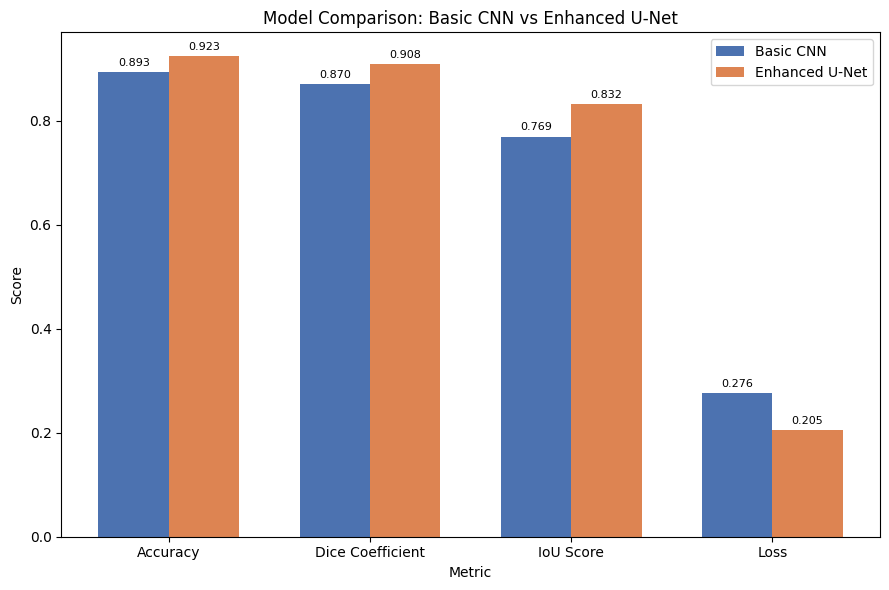

In [20]:
results_cnn = {'Model': 'Basic CNN', 'Accuracy': 0.8928, 'Dice Coefficient': 0.8695, 'IoU Score': 0.7691, 'Loss': 0.2762}
results_unet = {'Model': 'Enhanced U-Net', 'Accuracy': 0.9233, 'Dice Coefficient': 0.9080, 'IoU Score': 0.8316, 'Loss': 0.2051}

comparison_df = pd.DataFrame([results_cnn, results_unet])
print(comparison_df.to_string(index=False))
comparison_df.to_csv("model_comparison.csv", index=False)

improvement = {}
for metric in ["Accuracy", "Dice Coefficient", "IoU Score"]:
    pct_change = ((results_unet[metric] - results_cnn[metric]) / results_cnn[metric]) * 100
    improvement[metric] = round(pct_change, 2)

loss_change = ((results_cnn["Loss"] - results_unet["Loss"]) / results_cnn["Loss"]) * 100
improvement["Loss Reduction"] = round(loss_change, 2)

print("\nIMPROVEMENT: ENHANCED U-NET vs BASIC CNN")
for k, v in improvement.items():
    sign = "+" if v >= 0 else ""
    print(f"{k}: {sign}{v}%")

metrics = ["Accuracy", "Dice Coefficient", "IoU Score", "Loss"]
cnn_values = [results_cnn[m] for m in metrics]
unet_values = [results_unet[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, cnn_values, width, label="Basic CNN", color="#4C72B0")
bars2 = ax.bar(x + width/2, unet_values, width, label="Enhanced U-Net", color="#DD8452")

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Basic CNN vs Enhanced U-Net")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison_bar_chart.png", dpi=150)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


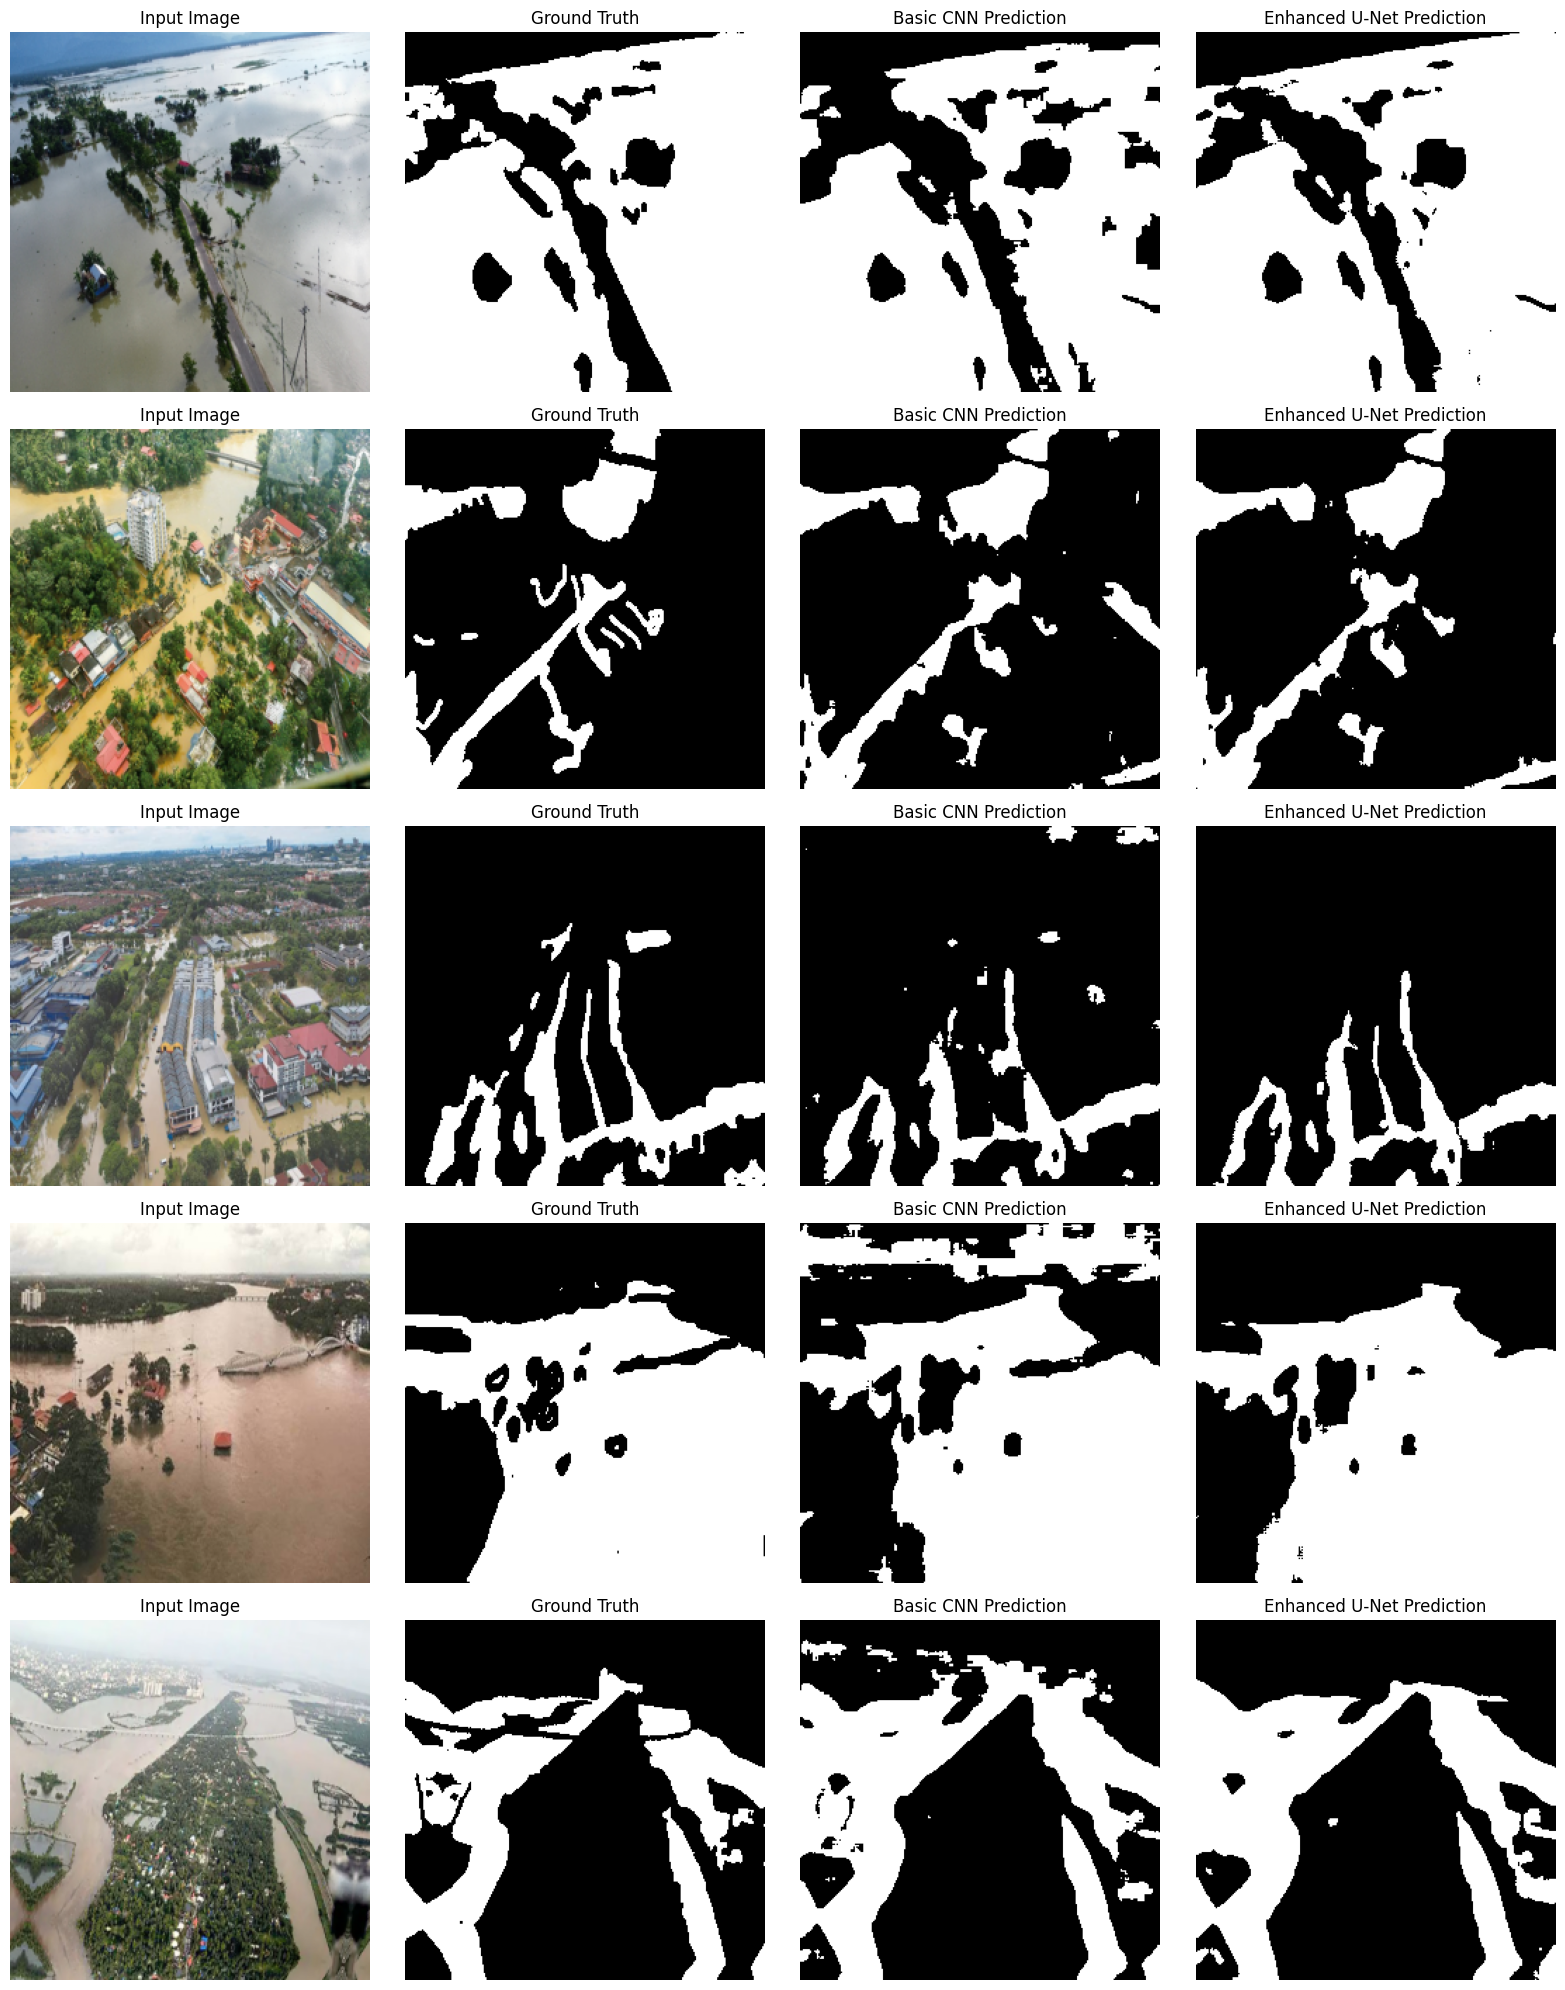

In [21]:
n_samples = 5
idxs = np.random.choice(len(X_test), n_samples, replace=False)

cnn_preds = basic_cnn.predict(X_test[idxs])
unet_preds = enhanced_unet.predict(X_test[idxs])

cnn_preds_bin = (cnn_preds > 0.5).astype(np.uint8)
unet_preds_bin = (unet_preds > 0.5).astype(np.uint8)

fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))

for i, idx in enumerate(idxs):
    axes[i, 0].imshow(X_test[idx])
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(Y_test[idx].squeeze(), cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(cnn_preds_bin[i].squeeze(), cmap="gray")
    axes[i, 2].set_title("Basic CNN Prediction")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(unet_preds_bin[i].squeeze(), cmap="gray")
    axes[i, 3].set_title("Enhanced U-Net Prediction")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.savefig("prediction_comparison_samples.png", dpi=150)
plt.show()

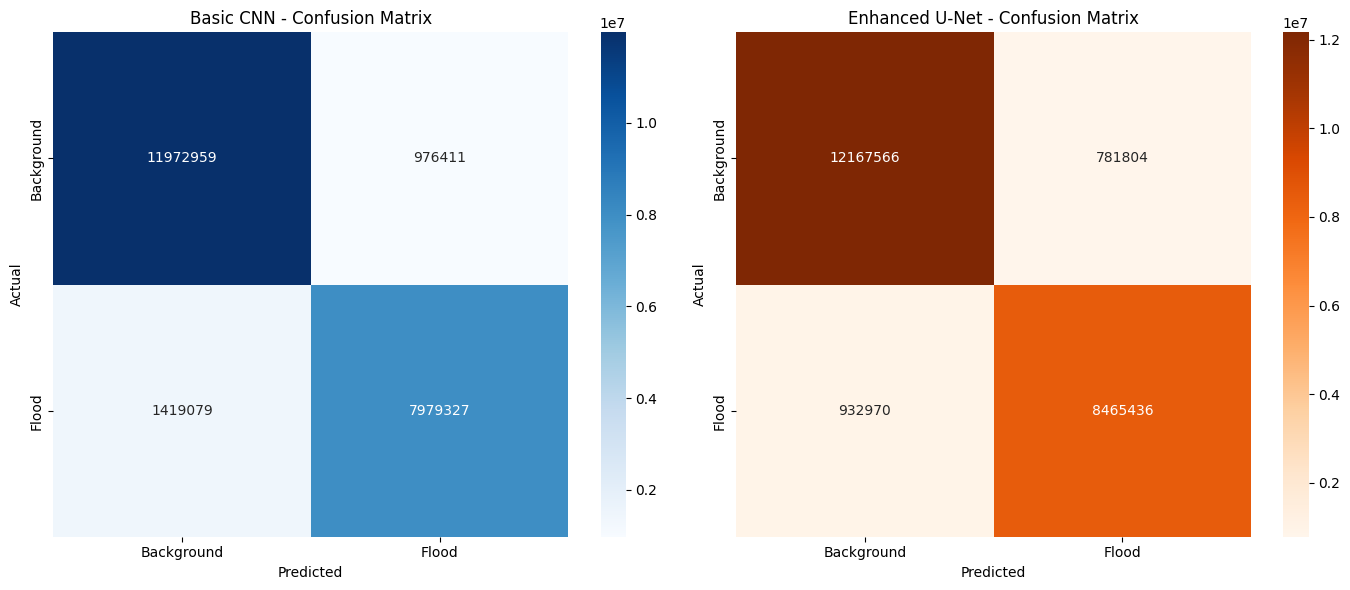

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def get_confusion_matrix(model, X_test, Y_test, name):
    y_pred_probs = model.predict(X_test, batch_size=16, verbose=0)
    y_pred_binary = (y_pred_probs > 0.5).astype(np.uint8).flatten()
    y_true_flat = Y_test.astype(np.uint8).flatten()

    cm = confusion_matrix(y_true_flat, y_pred_binary)
    return cm

cm_cnn = get_confusion_matrix(basic_cnn, X_test, Y_test, "Basic CNN")
cm_unet = get_confusion_matrix(enhanced_unet, X_test, Y_test, "Enhanced U-Net")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Background', 'Flood'],
            yticklabels=['Background', 'Flood'], ax=axes[0])
axes[0].set_title('Basic CNN - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_unet, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Background', 'Flood'],
            yticklabels=['Background', 'Flood'], ax=axes[1])
axes[1].set_title('Enhanced U-Net - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("confusion_matrices_comparison.png", dpi=150)
plt.show()

In [23]:
def cm_breakdown(cm, name):
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}")
    print(f"True Negatives  (correct background): {tn}")
    print(f"False Positives (predicted flood, actually background): {fp}")
    print(f"False Negatives (predicted background, actually flood): {fn}")
    print(f"True Positives  (correct flood): {tp}")
    print(f"False Positive Rate: {fp / (fp + tn):.4f}")
    print(f"False Negative Rate: {fn / (fn + tp):.4f}")

cm_breakdown(cm_cnn, "Basic CNN")
cm_breakdown(cm_unet, "Enhanced U-Net")


Basic CNN
True Negatives  (correct background): 11972959
False Positives (predicted flood, actually background): 976411
False Negatives (predicted background, actually flood): 1419079
True Positives  (correct flood): 7979327
False Positive Rate: 0.0754
False Negative Rate: 0.1510

Enhanced U-Net
True Negatives  (correct background): 12167566
False Positives (predicted flood, actually background): 781804
False Negatives (predicted background, actually flood): 932970
True Positives  (correct flood): 8465436
False Positive Rate: 0.0604
False Negative Rate: 0.0993


In [24]:
import time

def measure_inference_time(model, X_test, name, n_runs=3):
    times = []
    for _ in range(n_runs):
        start = time.time()
        _ = model.predict(X_test, batch_size=16, verbose=0)
        end = time.time()
        times.append(end - start)

    avg_time = np.mean(times)
    per_image_time = avg_time / len(X_test)

    print(f"{name}:")
    print(f"  Total time for {len(X_test)} images: {avg_time:.3f} sec")
    print(f"  Avg time per image: {per_image_time*1000:.3f} ms")
    print()

    return avg_time, per_image_time

cnn_total_time, cnn_per_image = measure_inference_time(basic_cnn, X_test, "Basic CNN")
unet_total_time, unet_per_image = measure_inference_time(enhanced_unet, X_test, "Enhanced U-Net")

speed_ratio = unet_total_time / cnn_total_time
print(f"Enhanced U-Net is {speed_ratio:.2f}x slower than Basic CNN" if speed_ratio > 1
      else f"Enhanced U-Net is {1/speed_ratio:.2f}x faster than Basic CNN")

Basic CNN:
  Total time for 341 images: 1.356 sec
  Avg time per image: 3.978 ms

Enhanced U-Net:
  Total time for 341 images: 3.149 sec
  Avg time per image: 9.234 ms

Enhanced U-Net is 2.32x slower than Basic CNN


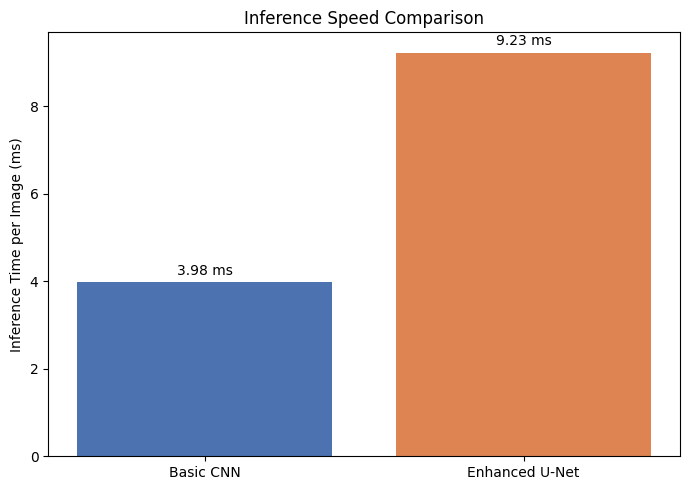

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
models = ['Basic CNN', 'Enhanced U-Net']
times_per_image_ms = [cnn_per_image * 1000, unet_per_image * 1000]

bars = ax.bar(models, times_per_image_ms, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Inference Time per Image (ms)')
ax.set_title('Inference Speed Comparison')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f} ms', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.savefig("inference_time_comparison.png", dpi=150)
plt.show()

In [26]:
summary = f"""
MODEL EVALUATION SUMMARY
=========================

Two models were evaluated on the held-out test set of {len(X_test)} images: a Basic CNN
and an Enhanced U-Net, both trained for flood segmentation from satellite imagery.

PERFORMANCE METRICS:
The Enhanced U-Net outperformed the Basic CNN across every metric. Accuracy improved
from {results_cnn['Accuracy']*100:.2f}% to {results_unet['Accuracy']*100:.2f}%
({improvement['Accuracy']:+.2f}%). The Dice Coefficient, which measures mask overlap
quality, rose from {results_cnn['Dice Coefficient']:.4f} to {results_unet['Dice Coefficient']:.4f}
({improvement['Dice Coefficient']:+.2f}%). The IoU Score showed the largest relative gain,
improving from {results_cnn['IoU Score']:.4f} to {results_unet['IoU Score']:.4f}
({improvement['IoU Score']:+.2f}%), indicating U-Net's predicted flood regions align far
more precisely with ground truth. Loss dropped from {results_cnn['Loss']:.4f} to
{results_unet['Loss']:.4f}, a reduction of {improvement['Loss Reduction']:.2f}%.

ERROR ANALYSIS:
Confusion matrix analysis shows Basic CNN had {cm_cnn[0,1]} false positives and
{cm_cnn[1,0]} false negatives at the pixel level, while Enhanced U-Net reduced these to
{cm_unet[0,1]} false positives and {cm_unet[1,0]} false negatives, reflecting fewer
misclassified flood/background pixels overall.

INFERENCE SPEED:
Basic CNN processes each image in approximately {cnn_per_image*1000:.2f} ms, while
Enhanced U-Net takes {unet_per_image*1000:.2f} ms per image. {"U-Net is slower due to its deeper architecture with skip connections, a reasonable trade-off given its accuracy gains." if unet_per_image > cnn_per_image else "U-Net is comparably fast despite its more complex architecture."}

CONCLUSION:
Given its clear advantage in segmentation accuracy (especially IoU) with an acceptable
inference cost, the Enhanced U-Net is recommended as the primary model for deployment
in this flood segmentation task.
"""

print(summary)

with open("evaluation_summary.txt", "w") as f:
    f.write(summary)


MODEL EVALUATION SUMMARY

Two models were evaluated on the held-out test set of 341 images: a Basic CNN
and an Enhanced U-Net, both trained for flood segmentation from satellite imagery.

PERFORMANCE METRICS:
The Enhanced U-Net outperformed the Basic CNN across every metric. Accuracy improved
from 89.28% to 92.33%
(+3.42%). The Dice Coefficient, which measures mask overlap
quality, rose from 0.8695 to 0.9080
(+4.43%). The IoU Score showed the largest relative gain,
improving from 0.7691 to 0.8316
(+8.13%), indicating U-Net's predicted flood regions align far
more precisely with ground truth. Loss dropped from 0.2762 to
0.2051, a reduction of 25.74%.

ERROR ANALYSIS:
Confusion matrix analysis shows Basic CNN had 976411 false positives and
1419079 false negatives at the pixel level, while Enhanced U-Net reduced these to
781804 false positives and 932970 false negatives, reflecting fewer
misclassified flood/background pixels overall.

INFERENCE SPEED:
Basic CNN processes each image in ap